## **Import Library**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

## **Mount Google Drive**

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


## **Load Dataset**

In [5]:
file_path = ('/content/drive/MyDrive/2. Belajar & Sertifikat/BNSP/dataset_ulasan_pelanggan.csv')

df = pd.read_csv(file_path)

## **Data Understanding**

### Dimensi Data

In [6]:
df.shape

(105, 6)

### Menampilkan Data

In [7]:
df.head()

,review_id,user_id,product_id,review_text,rating,review_date
0,R1000,U196,P10,tidak sesuai,3,14-12-2023
1,R1001,U122,P19,pelayanan buruk,1,14-03-2024
2,R1002,U188,P18,produk berkualitas,3,14-05-2023
3,R1003,U129,P14,cepat sampai,4,23-01-2023
4,R1004,U172,P14,harga sesuai,4,28-08-2024


### Informasi Data

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_id    105 non-null    object
 1   user_id      105 non-null    object
 2   product_id   105 non-null    object
 3   review_text  93 non-null     object
 4   rating       105 non-null    int64 
 5   review_date  105 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.1+ KB


### Cek Missing Value

In [9]:
df.isnull().sum()

,0
review_id,0
user_id,0
product_id,0
review_text,12
rating,0
review_date,0


### Statistik Deskriptif

In [10]:
df.describe()

,rating
count,105.000000
mean,2.961905
std,1.447304
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


### Cek Duplikat

In [11]:
print("Duplikat: ", df.duplicated().sum())

Duplikat:  5


## **Data Cleaning**

### Hapus Duplikat

In [12]:
df = df.drop_duplicates()

### Menangani Missing Value

In [13]:
df['review_text'] = df['review_text'].fillna('Tidak ada ulasan')

### Mengubah Format Tangga

In [14]:
df['review_date'] = pd.to_datetime(
    df['review_date'],
    format='%d-%m-%Y'
)

In [15]:
df.head()

,review_id,user_id,product_id,review_text,rating,review_date
0,R1000,U196,P10,tidak sesuai,3,2023-12-14
1,R1001,U122,P19,pelayanan buruk,1,2024-03-14
2,R1002,U188,P18,produk berkualitas,3,2023-05-14
3,R1003,U129,P14,cepat sampai,4,2023-01-23
4,R1004,U172,P14,harga sesuai,4,2024-08-28


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   review_id    100 non-null    object        
 1   user_id      100 non-null    object        
 2   product_id   100 non-null    object        
 3   review_text  100 non-null    object        
 4   rating       100 non-null    int64         
 5   review_date  100 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 5.5+ KB


## **Rule-Based Sentiment Labeling**

In [17]:
negative_words = [
    "tidak sesuai",
    "tidak puas",
    "tidak bagus",
    "lama",
    "terlambat",
    "kecewa",
    "mengecewakan",
    "buruk",
    "rusak",
    "jelek"
]

positive_words = [
    "sesuai",
    "bagus",
    "puas",
    "mantap",
    "berkualitas",
    "cepat"
]

In [18]:
def labeling_sentimen(review):

    if pd.isna(review):
        return "Netral"

    review = str(review).lower().strip()

    # negatif
    for kata in negative_words:
        if kata in review:
            return "Negatif"

    # positif
    for kata in positive_words:
        if kata in review:
            return "Positif"

    return "Netral"

df['label_sentimen'] = df['review_text'].apply(labeling_sentimen)

df[['review_text', 'label_sentimen']].head(20)

,review_text,label_sentimen
0,tidak sesuai,Negatif
1,pelayanan buruk,Negatif
2,produk berkualitas,Positif
3,cepat sampai,Positif
4,harga sesuai,Positif
5,pelayanan buruk,Negatif
6,Tidak ada ulasan,Netral
7,Tidak ada ulasan,Netral
8,tidak terlalu buruk,Negatif
9,harga sesuai,Positif


## **Exploratory Data Analysis (EDA)**

### Tren Review per Bulan

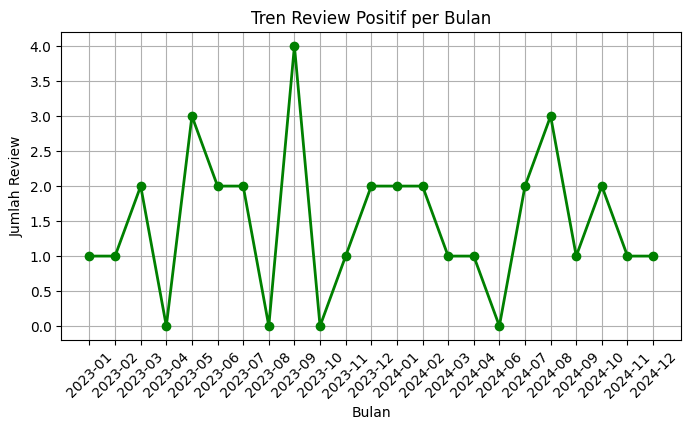

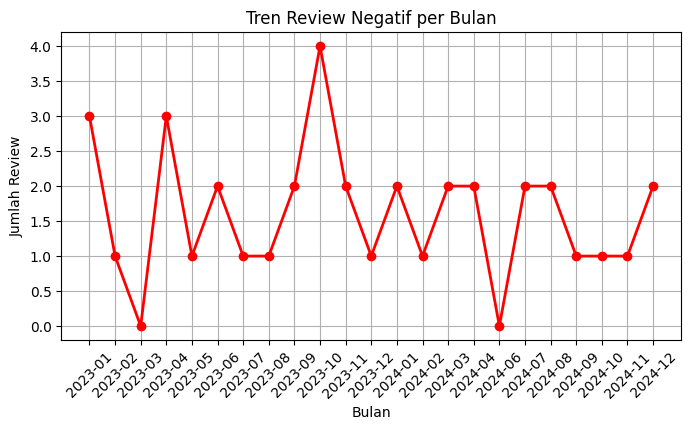

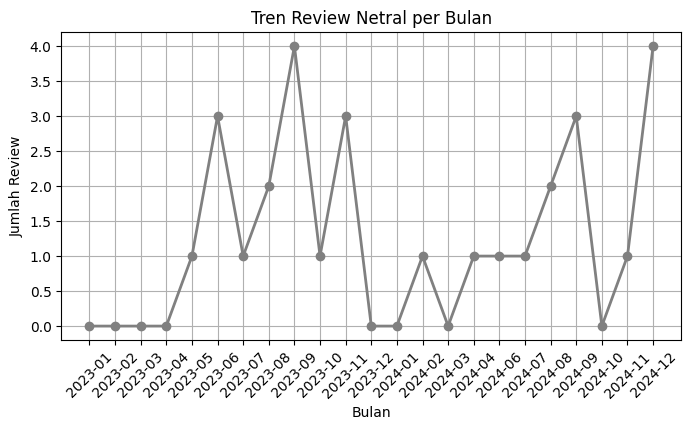

In [19]:
# Kolom Bulan
df['bulan'] = df['review_date'].dt.to_period('M').astype(str)

# Mengelompokkan data berdasarkan bulan dan label sentimen
trend = df.groupby(['bulan', 'label_sentimen']).size().unstack(fill_value=0)

# Grafik Tren Positif
plt.figure(figsize=(8,4))

plt.plot(trend.index, trend['Positif'],
         marker='o', linewidth=2, color='green')

plt.title('Tren Review Positif per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Review')
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

# Grafik Tren Negatif
plt.figure(figsize=(8,4))

plt.plot(trend.index, trend['Negatif'],
         marker='o', linewidth=2, color='red')

plt.title('Tren Review Negatif per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Review')
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

# Grafik Tren Netral
plt.figure(figsize=(8,4))

plt.plot(trend.index, trend['Netral'],
         marker='o', linewidth=2, color='gray')

plt.title('Tren Review Netral per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Review')
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

Insight:

1. Jumlah review positif berubah-ubah setiap bulan. Tidak ada peningkatan atau penurunan yang berlangsung terus-menerus.

2. Jumlah review negatif meningkat. Hal ini menunjukkan bahwa pada periode tersebut lebih banyak pelanggan yang merasa kurang puas

3. Jumlah review netral juga berubah setiap bulan. Review ini menunjukkan bahwa sebagian pelanggan memberikan penilaian yang biasa saja, tidak terlalu puas maupun tidak terlalu kecewa.

### Sebaran Label Sentimen

/tmp/ipykernel_9518/1297023882.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


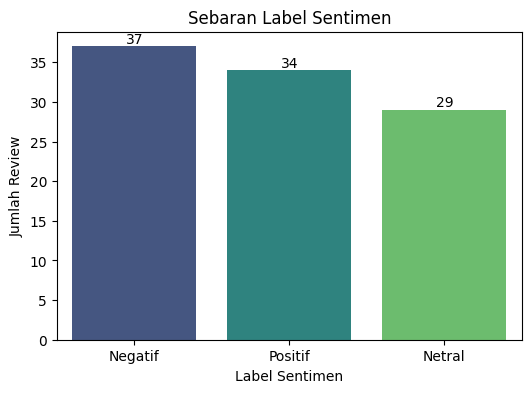

In [20]:
# jumlah setiap label sentimen
sentimen = df['label_sentimen'].value_counts()

# Ukuran gambar
plt.figure(figsize=(6,4))

# Grafik batang
sns.countplot(
    data=df,
    x='label_sentimen',
    order=sentimen.index,
    palette='viridis'
)

# Judul dan label
plt.title('Sebaran Label Sentimen')
plt.xlabel('Label Sentimen')
plt.ylabel('Jumlah Review')

# Menampilkan jumlah pada setiap batang
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.show()

Insight:

Jumlah review negatif sedikit lebih tinggi dibandingkan review positif. Kondisi ini menunjukkan bahwa masih terdapat produk atau layanan yang perlu dievaluasi

### Sebaran Rating

/tmp/ipykernel_9518/1821559826.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


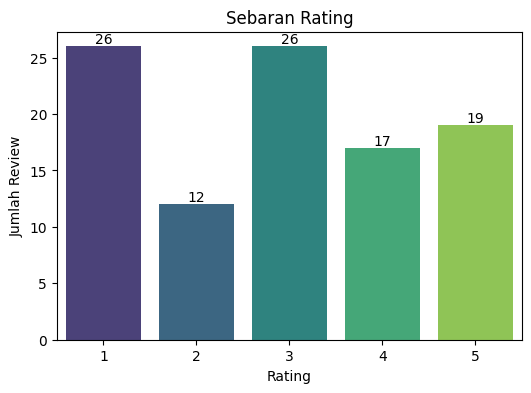

In [21]:
# Ukuran gambar
plt.figure(figsize=(6,4))

# Grafik batang
sns.countplot(
    data=df,
    x='rating',
    palette='viridis'
)

# Judul dan label
plt.title('Sebaran Rating')
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')

# jumlah setiap batang
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.show()

Insight:

Rating 1 dan 3 merupakan rating yang paling banyak diberikan pelanggan. Hal ini menunjukkan bahwa masih banyak pelanggan yang merasa kurang puas, meskipun sebagian pelanggan memberikan penilaian yang cukup baik. Kondisi ini menjadi masukan bagi perusahaan untuk meningkatkan kualitas produk maupun layanan.

### Distribusi Rating Berdasarkan Label Sentimen

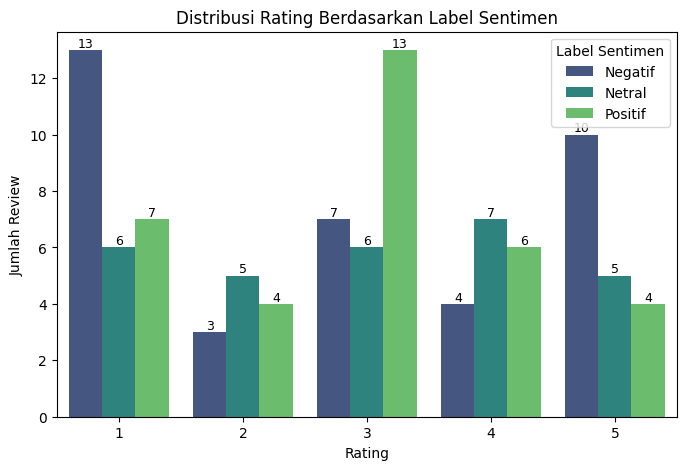

In [22]:
# ukuran gambar
plt.figure(figsize=(8,5))

# Membuat grafik batang
sns.countplot(
    data=df,
    x='rating',
    hue='label_sentimen',
    palette='viridis'
)

# Judul dan label
plt.title('Distribusi Rating Berdasarkan Label Sentimen')
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')

# jumlah setiap batang
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()

    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width()/2, height),
                    ha='center',
                    va='bottom',
                    fontsize=9)

plt.legend(title='Label Sentimen')
plt.show()

Insight:

1. Rating 1 didominasi oleh sentimen negatif.

    Ini menunjukkan bahwa pelanggan yang memberikan rating terendah umumnya merasa tidak puas terhadap produk atau layanan yang diterima.

2. Rating 3 didominasi oleh sentimen positif

    Meskipun merupakan rating sedang, cukup banyak pelanggan yang memberikan ulasan dengan kata-kata positif. Menunjukkan bahwa sebagian pelanggan tetap merasa puas meskipun tidak memberikan rating tertinggi

3. Rating 5 belum sepenuhnya menunjukkan sentimen positif

    Pada rating 5 masih ditemukan beberapa review yang berlabel negatif dan netral. Kondisi ini mengindikasikan bahwa terdapat ketidaksesuaian antara nilai rating yang diberikan dengan isi ulasan pelanggan

4. Review netral tersebar pada hampir semua rating

    Hal ini menunjukkan bahwa sebagian pelanggan memberikan penilaian yang tidak menunjukkan kepuasan maupun ketidakpuasan secara jelas


Kesimpulan:

Grafik menunjukkan bahwa terdapat hubungan antara rating yang diberikan pelanggan dengan sentimen ulasan. Rating rendah umumnya didominasi oleh sentimen negatif, sedangkan rating yang lebih tinggi cenderung memiliki lebih banyak sentimen positif. Namun, masih ditemukan beberapa perbedaan antara rating dan isi ulasan, sehingga perusahaan perlu menganalisis isi review secara lebih mendalam, tidak hanya mengandalkan nilai rating

### Produk dengan Ulasan Negatif Terbanyak

/tmp/ipykernel_9518/4054509209.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_produk_negatif.index, y=top_produk_negatif.values, palette='Reds_r')


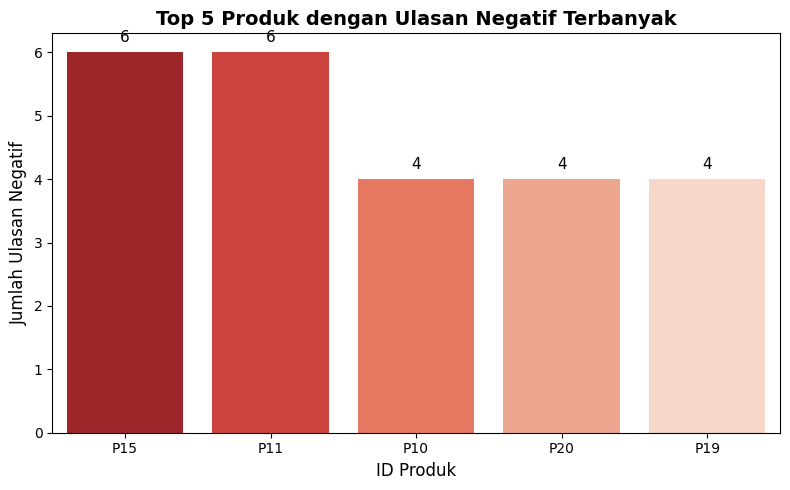

In [23]:
# Ulasan 'Negatif'
df_negatif = df[df['label_sentimen'] == 'Negatif']

# Jumlah ulasan negatif 'product_id'
top_produk_negatif = df_negatif['product_id'].value_counts().head(5)

# Visualisasi
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=top_produk_negatif.index, y=top_produk_negatif.values, palette='Reds_r')

# Judul dan label sumbu
plt.title('Top 5 Produk dengan Ulasan Negatif Terbanyak', fontsize=14, fontweight='bold')
plt.xlabel('ID Produk', fontsize=12)
plt.ylabel('Jumlah Ulasan Negatif', fontsize=12)

# Total tiap batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points',
                fontsize=11)

plt.tight_layout()
plt.show()

Insight:

Berdasarkan analisis lanjutan, komplain dan ulasan negatif dari pelanggan tidak tersebar merata di semua produk. Mayoritas ulasan negatif terkonsentrasi pada beberapa produk spesifik, terutama pada produk dengan ID [P15, P11]."

## **Analisis Korelasi**

Analisis korelasi tidak dilakukan karena dataset hanya memiliki satu variabel numerik, yaitu rating, sehingga tidak memenuhi syarat untuk menghitung korelasi antarvariabel numerik.

## **Business Recommendation**

1. **Fokus Evaluasi pada Produk P15 dan P11:**

    Berdasarkan data persebaran sentimen negatif terhadap ID Produk, ditemukan bahwa komplain pelanggan tidak tersebar merata. Ulasan negatif paling banyak terkonsentrasi pada produk dengan ID P15 dan P11 yang masing-masing menerima 6 ulasan negatif. Disarankan agar manajemen dan tim Quality Control (QC) segera menarik, meninjau fisik, atau memperbaiki kualitas kedua produk tersebut.

2. **Investigasi Anomali Rating:**

    Terdapat ketidaksesuaian antara pemberian rating dan isi ulasan. Ditemukan bahwa pada kelompok rating tertinggi (Rating 5), masih terdapat ulasan berlabel sentimen "negatif" dan "netral". Manajemen disarankan untuk berkoordinasi dengan tim IT/Produk guna menginvestigasi User Interface (UI) aplikasi; apakah ada kemungkinan pelanggan salah klik saat memberikan rating, atau ada kekeliruan sistematis

3. **Tinjauan Ulang Pemahaman Rating 3:**
    
    Data menunjukkan bahwa Rating 3 bukan sekadar nilai tengah yang aman. Rating ini ternyata didominasi oleh ulasan bersentimen positif. Ini mengindikasikan bahwa sebagian besar pelanggan merasa puas, namun ada "harapan yang belum terpenuhi" sehingga mereka tidak memberikan Rating 5. Manajemen perlu mempelajari secara spesifik isi teks ulasan di Rating 3 ini untuk menemukan insight tentang fitur/layanan tambahan apa yang diinginkan pelanggan

4. **Antisipasi Lonjakan Kekecewaan Musiman:**
    
    Grafik "Tren Review Negatif per Bulan" menunjukkan bahwa ada bulan-bulan tertentu (seperti bulan September) di mana terjadi lonjakan keluhan pelanggan yang signifikan. Manajemen disarankan untuk melakukan cross-check riwayat operasional pada bulan tersebut (misalnya, apakah ada gagal panen, event promo besar yang membuat logistik kewalahan, atau masalah pada vendor) agar kendala serupa dapat diantisipasi di periode mendatang.

## **Simpan CSV**

In [24]:
df.to_csv('hasil_sentimen.csv', index=False)